# Kalman Filter Based Team Strength

Final modelling notebook. Failed exploratory branches have been removed; this notebook keeps only the validation path that produced a robust improvement over the provided baseline.


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import PoissonRegressor, Ridge
from sklearn.pipeline import Pipeline

from kalman_features import KF_OBSERVATION_VAR, KF_PROCESS_VAR, build_kalman_features
from utility_functions import (
    CORE_SEASONS,
    FEATURE_COLS,
    TRAIN_SEASONS,
    TUNE_SEASONS,
    VAL_SEASONS,
    composite_loss,
    fill_missing_kf_attack_with_prior,
    load_data,
    make_cold_start_prior_model,
    score,
)

DATA_DIR = Path.cwd()
INPUT_DIR = DATA_DIR / "inputs"
OUTPUT_DIR = DATA_DIR / "outputs"

labelled_rows, holdout_rows = load_data(INPUT_DIR)
baseline_val = pd.read_csv(INPUT_DIR / "baseline_validation_predictions.csv")

print(f"labelled: {len(labelled_rows) // 2:,} matches, seasons {labelled_rows.season.min()}-{labelled_rows.season.max()}")
print(f"holdout : {len(holdout_rows) // 2:,} matches, dates {holdout_rows.date.min().date()} to {holdout_rows.date.max().date()}")


labelled: 2,090 matches, seasons 2012-2022
holdout : 760 matches, dates 2023-08-11 to 2027-05-14


## Honest Feature Construction

Validation rows are masked before the Kalman filter runs. Their labels are reattached only after feature construction for scoring. This means TUNE/VAL results cannot update team states or the global home advantage.


In [2]:
def mask_corners(rows: pd.DataFrame) -> pd.DataFrame:
    """Return a copy whose corners cannot update Kalman states."""
    masked = rows.copy()
    masked["corners"] = pd.NA
    return masked


def attach_observed_corners(feature_rows: pd.DataFrame, label_rows: pd.DataFrame) -> pd.DataFrame:
    """Reattach labels after honest feature construction."""
    labels = label_rows[["match_id", "team", "corners"]]
    return feature_rows.drop(columns=["corners"], errors="ignore").merge(
        labels, on=["match_id", "team"], how="left"
    )


def build_honest_kf_split(
    fit_rows: pd.DataFrame,
    predict_rows: pd.DataFrame | None = None,
    *,
    process_var: float = KF_PROCESS_VAR,
    observation_var: float = KF_OBSERVATION_VAR,
) -> pd.DataFrame:
    """Fit-time rows are labelled; prediction rows are present but label-masked."""
    sequence_parts = [fit_rows.copy()]
    if predict_rows is not None:
        sequence_parts.append(mask_corners(predict_rows))
    sequence = pd.concat(sequence_parts, ignore_index=True)
    return build_kalman_features(
        sequence,
        process_var=process_var,
        observation_var=observation_var,
    )


core_labels = labelled_rows[labelled_rows["season"].isin(CORE_SEASONS)].copy()
tune_labels = labelled_rows[labelled_rows["season"].isin(TUNE_SEASONS)].copy()
train_labels = labelled_rows[labelled_rows["season"].isin(TRAIN_SEASONS)].copy()
val_labels = labelled_rows[labelled_rows["season"].isin(VAL_SEASONS)].copy()

core_tune_kf = build_honest_kf_split(core_labels, tune_labels)
core_features = attach_observed_corners(
    core_tune_kf[core_tune_kf["season"].isin(CORE_SEASONS)], core_labels
)
tune_features = attach_observed_corners(
    core_tune_kf[core_tune_kf["season"].isin(TUNE_SEASONS)], tune_labels
)

train_val_kf = build_honest_kf_split(train_labels, val_labels)
train_features = attach_observed_corners(
    train_val_kf[train_val_kf["season"].isin(TRAIN_SEASONS)], train_labels
)
val_features = attach_observed_corners(
    train_val_kf[train_val_kf["season"].isin(VAL_SEASONS)], val_labels
)

cold_start_matches = train_features["kf_attack"].isna().sum() // 2
print(f"Cold-start TRAIN matches without enough KF history: {cold_start_matches:,}")


Cold-start TRAIN matches without enough KF history: 165


## Feature Signal Check

`kf_attack` is the only Kalman feature that consistently improves the final Poisson model. Defence and opponent KF columns are kept for ablation, but not selected unless they beat `kf_attack` on TUNE.


Correlation with corners on TRAIN rows after KF warm-up:
feature_8     0.4110
kf_attack     0.2731
feature_7     0.2507
home          0.1640
feature_4     0.1221
feature_3     0.0701
feature_9     0.0669
feature_5    -0.0409
feature_1     0.0334
feature_6    -0.0156
feature_10   -0.0141
feature_2     0.0045


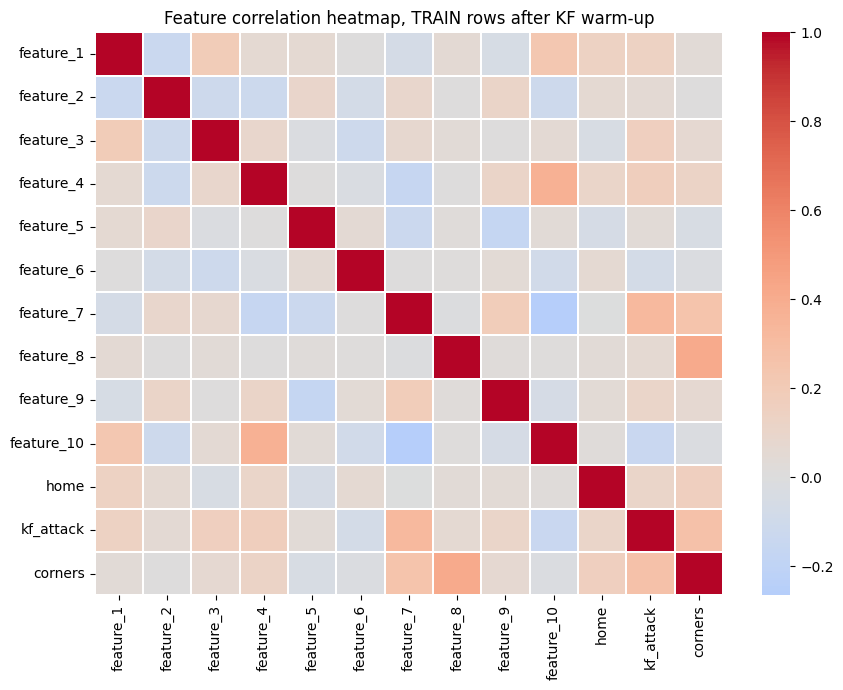

In [3]:
BASE_FEATURES = FEATURE_COLS + ["home"]
KF_FEATURES = ["kf_attack", "kf_defense", "opp_kf_attack", "opp_kf_defense"]
DEFAULT_MODEL_FEATURES = BASE_FEATURES + ["kf_attack"]

train_ready = train_features.dropna(subset=["kf_attack"])
correlations = (
    train_ready[FEATURE_COLS + ["home", "kf_attack", "corners"]]
    .corrwith(train_ready["corners"])
    .drop("corners")
    .sort_values(key=abs, ascending=False)
)
print("Correlation with corners on TRAIN rows after KF warm-up:")
print(correlations.round(4).to_string())

plt.figure(figsize=(9, 7))
heatmap_cols = FEATURE_COLS + ["home", "kf_attack", "corners"]
sns.heatmap(train_ready[heatmap_cols].corr(), cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Feature correlation heatmap, TRAIN rows after KF warm-up")
plt.tight_layout()
plt.show()


## Model And Hyperparameter Selection

All choices below use CORE -> TUNE only. VAL is not touched until the final cell.


In [4]:
core_model_rows = core_features.dropna(subset=["kf_attack"])
tune_model_rows = tune_features.dropna(subset=["kf_attack"])
y_core = core_model_rows["corners"].to_numpy(float)
y_tune = tune_model_rows["corners"].to_numpy(float)


def fit_predict(estimator, train_rows: pd.DataFrame, eval_rows: pd.DataFrame, feature_cols: list[str]) -> np.ndarray:
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("estimator", estimator),
    ])
    model.fit(train_rows[feature_cols], train_rows["corners"].to_numpy(float))
    return model.predict(eval_rows[feature_cols])


print("Ridge alpha sweep on honest TUNE:")
ridge_scores = {}
for alpha in [1.0, 5.0, 10.0, 50.0, 100.0]:
    preds = fit_predict(Ridge(alpha=alpha), core_model_rows, tune_model_rows, DEFAULT_MODEL_FEATURES)
    ridge_scores[alpha] = composite_loss(y_tune, preds)
    score(f"Ridge alpha={alpha}", y_tune, preds, width=28)
best_ridge_alpha = min(ridge_scores, key=ridge_scores.get)

print("\nPoisson alpha sweep on honest TUNE:")
poisson_scores = {}
for alpha in [0.1, 0.5, 1.0, 2.0, 5.0]:
    preds = fit_predict(
        PoissonRegressor(alpha=alpha, max_iter=1000),
        core_model_rows,
        tune_model_rows,
        DEFAULT_MODEL_FEATURES,
    )
    poisson_scores[alpha] = composite_loss(y_tune, preds)
    score(f"Poisson alpha={alpha}", y_tune, preds, width=28)
best_poisson_alpha = min(poisson_scores, key=poisson_scores.get)

print(f"\nSelected: Ridge alpha={best_ridge_alpha}, Poisson alpha={best_poisson_alpha}")


Ridge alpha sweep on honest TUNE:
Ridge alpha=1.0              MAE=2.1721  RMSE=2.7009  PoissonDev=1.3699
Ridge alpha=5.0              MAE=2.1604  RMSE=2.6863  PoissonDev=1.3582
Ridge alpha=10.0             MAE=2.1524  RMSE=2.6746  PoissonDev=1.3495
Ridge alpha=50.0             MAE=2.1636  RMSE=2.6763  PoissonDev=1.3581
Ridge alpha=100.0            MAE=2.1917  RMSE=2.7148  PoissonDev=1.3942

Poisson alpha sweep on honest TUNE:


Poisson alpha=0.1            MAE=2.1399  RMSE=2.6496  PoissonDev=1.3379
Poisson alpha=0.5            MAE=2.2092  RMSE=2.7449  PoissonDev=1.4248
Poisson alpha=1.0            MAE=2.2433  RMSE=2.7998  PoissonDev=1.4742
Poisson alpha=2.0            MAE=2.2716  RMSE=2.8450  PoissonDev=1.5157
Poisson alpha=5.0            MAE=2.2966  RMSE=2.8937  PoissonDev=1.5614

Selected: Ridge alpha=10.0, Poisson alpha=0.1


In [5]:
# process_var: how quickly team strength is allowed to drift.
# observation_var: how noisy one match is. Larger values make updates more conservative.
PROCESS_VAR_GRID = [0.03, 0.05, 0.10, 0.15, 0.30, 0.50, 1.00, 2.00]
OBSERVATION_VAR_GRID = [3.0, 5.0, 8.0, 11.0, 15.0, 20.0, 30.0]

kf_search_rows = []
for process_var in PROCESS_VAR_GRID:
    for observation_var in OBSERVATION_VAR_GRID:
        candidate_kf = build_honest_kf_split(
            core_labels,
            tune_labels,
            process_var=process_var,
            observation_var=observation_var,
        )
        candidate_core = attach_observed_corners(
            candidate_kf[candidate_kf["season"].isin(CORE_SEASONS)], core_labels
        ).dropna(subset=["kf_attack"])
        candidate_tune = attach_observed_corners(
            candidate_kf[candidate_kf["season"].isin(TUNE_SEASONS)], tune_labels
        ).dropna(subset=["kf_attack"])
        preds = fit_predict(
            PoissonRegressor(alpha=best_poisson_alpha, max_iter=1000),
            candidate_core,
            candidate_tune,
            DEFAULT_MODEL_FEATURES,
        )
        kf_search_rows.append({
            "process_var": process_var,
            "observation_var": observation_var,
            "composite": composite_loss(candidate_tune["corners"].to_numpy(float), preds),
        })

kf_search = pd.DataFrame(kf_search_rows).sort_values("composite").reset_index(drop=True)
best_process_var = float(kf_search.loc[0, "process_var"])
best_observation_var = float(kf_search.loc[0, "observation_var"])

print("Top KF settings on honest TUNE:")
print(kf_search.head(10).round(4).to_string(index=False))
print(f"\nSelected: process_var={best_process_var}, observation_var={best_observation_var}")


Top KF settings on honest TUNE:
 process_var  observation_var  composite
        0.03             30.0     1.8663
        0.05             30.0     1.8681
        0.03             20.0     1.8683
        0.03             15.0     1.8702
        0.05             20.0     1.8710
        0.10             30.0     1.8720
        0.03             11.0     1.8726
        0.05             15.0     1.8733
        0.15             30.0     1.8747
        0.03              8.0     1.8754

Selected: process_var=0.03, observation_var=30.0


In [6]:
selection_kf = build_honest_kf_split(
    core_labels,
    tune_labels,
    process_var=best_process_var,
    observation_var=best_observation_var,
)
selection_core = attach_observed_corners(
    selection_kf[selection_kf["season"].isin(CORE_SEASONS)], core_labels
).dropna(subset=["kf_attack"])
selection_tune = attach_observed_corners(
    selection_kf[selection_kf["season"].isin(TUNE_SEASONS)], tune_labels
).dropna(subset=["kf_attack"])
y_selection_tune = selection_tune["corners"].to_numpy(float)

team_strength_groups = {
    "no KF": [],
    "kf_attack": ["kf_attack"],
    "kf_attack + kf_defense": ["kf_attack", "kf_defense"],
    "all KF": KF_FEATURES,
}

print("Team-strength feature ablation on honest TUNE:")
team_strength_scores = {}
for label, extra_cols in team_strength_groups.items():
    feature_cols = BASE_FEATURES + extra_cols
    preds = fit_predict(
        PoissonRegressor(alpha=best_poisson_alpha, max_iter=1000),
        selection_core,
        selection_tune,
        feature_cols,
    )
    team_strength_scores[label] = composite_loss(y_selection_tune, preds)
    score(label, y_selection_tune, preds, width=28)

best_team_strength_label = min(team_strength_scores, key=team_strength_scores.get)
TEAM_STRENGTH_FEATURES = team_strength_groups[best_team_strength_label]
FINAL_MODEL_FEATURES = BASE_FEATURES + TEAM_STRENGTH_FEATURES

print(f"\nSelected team-strength group: {best_team_strength_label}")
print(f"FINAL_MODEL_FEATURES = {FINAL_MODEL_FEATURES}")


Team-strength feature ablation on honest TUNE:
no KF                        MAE=2.1683  RMSE=2.6954  PoissonDev=1.3753
kf_attack                    MAE=2.1399  RMSE=2.6496  PoissonDev=1.3379
kf_attack + kf_defense       MAE=2.1404  RMSE=2.6498  PoissonDev=1.3380
all KF                       MAE=2.1465  RMSE=2.6575  PoissonDev=1.3439

Selected team-strength group: kf_attack
FINAL_MODEL_FEATURES = ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'home', 'kf_attack']


## Cold-Start KF Attack Prior

Some prediction rows have no reliable `kf_attack` because the team or opponent has not reached the KF warm-up threshold. Instead of filling all missing values with one global mean, a small regularised tree prior predicts only the missing `kf_attack` values from `feature_1..10` and `home`. Existing KF values are preserved.




In [7]:
def fit_predict_final_model(
    train_rows: pd.DataFrame,
    eval_rows: pd.DataFrame,
    feature_cols: list[str],
    *,
    alpha: float = best_poisson_alpha,
) -> np.ndarray:
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("poisson", PoissonRegressor(alpha=alpha, max_iter=1000)),
    ])
    model.fit(train_rows[feature_cols], train_rows["corners"].to_numpy(float))
    return model.predict(eval_rows[feature_cols])


selection_core_all = attach_observed_corners(
    selection_kf[selection_kf["season"].isin(CORE_SEASONS)], core_labels
)
selection_tune_all = attach_observed_corners(
    selection_kf[selection_kf["season"].isin(TUNE_SEASONS)], tune_labels
)
selection_core_known = selection_core_all.dropna(subset=["kf_attack"])
y_selection_tune_all = selection_tune_all["corners"].to_numpy(float)

print("Cold-start kf_attack fill on honest TUNE, keeping cold-start eval rows:")
mean_fill_preds = fit_predict_final_model(
    selection_core_known,
    selection_tune_all,
    FINAL_MODEL_FEATURES,
)
score("mean-imputed kf_attack", y_selection_tune_all, mean_fill_preds, width=32)

core_filled, _ = fill_missing_kf_attack_with_prior(
    selection_core_known,
    selection_core_known,
    make_cold_start_prior_model(),
)
tune_filled, _ = fill_missing_kf_attack_with_prior(
    selection_core_known,
    selection_tune_all,
    make_cold_start_prior_model(),
)
FINAL_MODEL_FEATURES_FILLED = BASE_FEATURES + ["kf_attack_filled"]
preds = fit_predict_final_model(core_filled, tune_filled, FINAL_MODEL_FEATURES_FILLED)
score("HGB cold-start prior", y_selection_tune_all, preds, width=32)
print(f"\nFINAL_MODEL_FEATURES_FILLED = {FINAL_MODEL_FEATURES_FILLED}")






Cold-start kf_attack fill on honest TUNE, keeping cold-start eval rows:
mean-imputed kf_attack           MAE=2.1638  RMSE=2.6938  PoissonDev=1.3699


HGB cold-start prior             MAE=2.1460  RMSE=2.6685  PoissonDev=1.3503

FINAL_MODEL_FEATURES_FILLED = ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'home', 'kf_attack_filled']


## Final One-Shot Validation

The final model is fitted on TRAIN seasons 2012-2019. VAL seasons 2020-2022 are masked during KF construction, then scored once.


In [8]:
final_kf = build_honest_kf_split(
    train_labels,
    val_labels,
    process_var=best_process_var,
    observation_var=best_observation_var,
)
final_train_all = attach_observed_corners(
    final_kf[final_kf["season"].isin(TRAIN_SEASONS)], train_labels
)
final_train_known = final_train_all.dropna(subset=["kf_attack"])
final_val_rows = attach_observed_corners(
    final_kf[final_kf["season"].isin(VAL_SEASONS)], val_labels
).merge(baseline_val, on=["match_id", "team"])

y_train_final = final_train_known["corners"].to_numpy(float)
y_val_final = final_val_rows["corners"].to_numpy(float)
y_baseline = final_val_rows["baseline_predicted_corners"].to_numpy(float)

train_filled, _ = fill_missing_kf_attack_with_prior(
    final_train_known,
    final_train_known,
    make_cold_start_prior_model(),
)
val_filled, _ = fill_missing_kf_attack_with_prior(
    final_train_known,
    final_val_rows,
    make_cold_start_prior_model(),
)

ridge_final = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("ridge", Ridge(alpha=best_ridge_alpha)),
])
poisson_mean_fill = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("poisson", PoissonRegressor(alpha=best_poisson_alpha, max_iter=1000)),
])
poisson_filled = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("poisson", PoissonRegressor(alpha=best_poisson_alpha, max_iter=1000)),
])

ridge_final.fit(final_train_known[FINAL_MODEL_FEATURES], y_train_final)
poisson_mean_fill.fit(final_train_known[FINAL_MODEL_FEATURES], y_train_final)
poisson_filled.fit(train_filled[FINAL_MODEL_FEATURES_FILLED], y_train_final)

ridge_predictions = ridge_final.predict(final_val_rows[FINAL_MODEL_FEATURES])
poisson_mean_predictions = poisson_mean_fill.predict(final_val_rows[FINAL_MODEL_FEATURES])
poisson_cold_start_predictions = poisson_filled.predict(val_filled[FINAL_MODEL_FEATURES_FILLED])

score("Baseline", y_val_final, y_baseline)
score(f"Ridge + {best_team_strength_label}", y_val_final, ridge_predictions)
score("Poisson + mean-imputed kf_attack", y_val_final, poisson_mean_predictions)
score("Poisson + cold-start kf prior", y_val_final, poisson_cold_start_predictions)

validation_comparison = final_val_rows[[
    "match_id",
    "team",
    "corners",
    "baseline_predicted_corners",
]].rename(columns={"corners": "actual_corners"})
validation_comparison["poisson_mean_imputed_kf_attack"] = poisson_mean_predictions
validation_comparison["poisson_cold_start_kf_prior"] = poisson_cold_start_predictions
validation_comparison["ridge_kf_predicted_corners"] = ridge_predictions

OUTPUT_DIR.mkdir(exist_ok=True)
comparison_path = OUTPUT_DIR / "validation_predictions_comparison.csv"
validation_comparison.to_csv(comparison_path, index=False)
print()
print(f"Saved {comparison_path} ({len(validation_comparison):,} rows)")


Baseline                         MAE=2.2717  RMSE=2.8574  PoissonDev=1.3406
Ridge + kf_attack                MAE=2.1993  RMSE=2.7736  PoissonDev=1.2942
Poisson + mean-imputed kf_attack MAE=2.1712  RMSE=2.7349  PoissonDev=1.2574
Poisson + cold-start kf prior    MAE=2.1588  RMSE=2.7196  PoissonDev=1.2437

Saved C:\backup\football_corner_forecast\outputs\validation_predictions_comparison.csv (1,140 rows)
